# **INITIAL EXPLORATORY ANALYSIS - Vannie Nguyen**

## **Data Selection**

**Dataset**: 2023 Medical Expenditure Panel Survey (MEPS) Full-Year Consolidated Data File (HC-251)

**Source**: Agency for HealthcareResearch and Quality (AHRQ), Medical Expenditure Panel Survey (MEPS)

**Source URL**: https://meps.ahrq.gov/mepsweb/data_stats/download_data_files_detail.jsp?cboPufNumber=HC-251

**Note for downloading the dataset**: The raw dataset is not included in this repository because of its file size. Download the data as 'MEPS2023'
1. Visit the official MEPS HC-251 download page:
   https://meps.ahrq.gov/mepsweb/data_stats/download_data_files_detail.jsp?cboPufNumber=HC-251

2. Under the **Data File, XLSX format** option, download the **ZIP**
   file.

3. Extract/unzip the downloaded file.

4. Rename the extracted Excel file to:
   `MEPS2023.xlsx`

5. Upload `MEPS2023.xlsx` when prompted by the Google Colab notebook.
The notebook expects the dataset to be named `MEPS2023.xlsx`.

Please allow approximately 10 minutes for the dataset to fully load in Google Colab. Loading time may vary depending on your internet connection and Colab's available resources.

---
The dataset selected for this project is the 2023 Medical Expenditure Panel Survey (MEPS) Full-Year Consolidated Data File (HC-251) from the Agency for Healthcare Research and Quality (AHRQ). MEPS is a nationally representative survey of the U.S. civilian noninstitutionalized population and contains information on healthcare access, utilization, health insurance, health stauts, demographics, income, and healthcare expenditures. The 2023 Full-Year Consolidated File contains data from 2023 and includes respondents from MEPS Panels 27 and 28.

This dataset was selected because it aligns closely with my academic and professional interests in healthcare access, health disparities, and health data. Satisfying the required criteria, this dataset provides an appropriate binary outcome for examining whether demographic, socioeconomic, and health-related characteristics can be used to predict delayed medical care.

The dataset satisfies the required criteria, including:
- *Binary classification*: The target variable can be recorded into a binary outcome where respondents who reported delaying medical care because of cost are coded as 1 and those who did not are coded as 0.

- *Minimum of 200 observations*: The detaset contains 18,919 observations, which is substantially greater than the required minimum of 300 observations.

- *Minimum of 10 predictor variables*: The MEPS Full-Year Consolidated File contains 1,374 variables in the version used for this project, providing substantially more than the required minimum of 10 potential predictor variables. Candidate predictors for this project include health insurance coverage, income/poverty category, age, sex, health status, and potentially health-related characteristics.

- *Alignment with academic interests*: MEPS provides data related to healthcare access and utilization, which aligns with my interests in public health, healthcare data science, and understanding factors associated with barriers to healthcare.





## **Dataset Exploration**
- Import the dataset into Google Colab.
- Examine the dataset structure.
- Identify the target variable.
- Describe the predictor variables.
- Compute descriptive statistics.
- Generate at least two exploratory visualizations.

In [6]:
# import libraries
import pandas as pd
from google.colab import files

# Upload the MEPS 2023 dataset
uploaded = files.upload()

# Load the MEPS 2023 dataset into a pandas DataFrame
df = pd.read_excel("MEPS2023.xlsx")

# file_path = "/content/drive/MyDrive/Colab Notebooks/HSE751/MEPS2023.xlsx"
# df = pd.read_excel(file_path)

Saving MEPS2023.xlsx to MEPS2023.xlsx


In [31]:
# checking # of rows and columns in the dataset
df.shape

(18919, 1374)

In [8]:
# preview first 10 rows of the dataset
df.head(10)

,DUID,PID,DUPERSID,PANEL,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID23,FAMIDYR,...,RXWCP23,RXOSR23,RXPTR23,RXOTH23,PERWT23F,FAMWT23F,FAMWT23C,SAQWT23F,VARSTR,VARPSU
0,2790002,101,2790002101,27,2023,A,A,A,A,A,...,0,0,82,0,11664.426815,11158.817826,11158.817826,13221.315673,2019,1
1,2790002,102,2790002102,27,2023,A,A,A,A,A,...,0,0,0,0,32212.113596,11158.817826,11158.817826,0.000000,2019,1
2,2790004,101,2790004101,27,2023,A,A,A,A,A,...,0,0,0,0,21944.142826,28540.745942,28540.745942,29999.277476,2084,1
3,2790006,101,2790006101,27,2023,A,A,A,A,A,...,0,0,0,0,10328.009530,10821.040689,10821.040689,11144.513916,2113,1
4,2790006,102,2790006102,27,2023,A,A,A,A,A,...,0,0,0,0,17430.521357,10821.040689,10821.040689,0.000000,2113,1
5,2790007,101,2790007101,27,2023,A,A,A,A,A,...,0,0,0,0,20123.370293,24659.806620,24659.806620,80674.378176,2085,3
6,2790011,101,2790011101,27,2023,A,A,A,A,A,...,0,0,0,0,13467.394415,12978.856984,12978.856984,12884.246699,2029,3
7,2790011,102,2790011102,27,2023,A,A,A,A,A,...,0,0,28,0,10754.599229,12978.856984,12978.856984,10855.226656,2029,3
8,2790012,101,2790012101,27,2023,A,A,A,A,A,...,0,0,11842,0,16830.149494,17072.453528,17072.453528,33671.560705,2055,2
9,2790012,102,2790012102,27,2023,A,A,A,A,A,...,0,0,10,0,28343.219605,17072.453528,17072.453528,53013.904136,2055,2


In [9]:
# review the variables, data types, and non-missing observations
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18919 entries, 0 to 18918
Columns: 1374 entries, DUID to VARPSU
dtypes: float64(16), int64(1347), object(11)
memory usage: 198.3+ MB


### **Target variable:** **DLAYCA42**

The target variable for this classification project is DLAYCA42, which measures whether a respondent delayed medical care because of cost. The variable is coded as 1 = YES an d 2 = NO. MEPS includes special codes for Don't Know (-8), Refuse (-7), and Inapplicable (-1). These special codes will be treated as missing values during data processing. Among the 18,919 observations, 1156 respondents reported delaying medical care because of cost, while 17,436 reported that they did not.

Among respondents with valid responses for DLAYCA42, 6.22% reported delaying medical care because of cost, while 93.78% reported that they did not delay medical care because of lost. This indicates that the target variable is highly imbalanced, with substantially fewer respondents in the delayed-care group. Class imbalance will therefore be considered when evaluating the classification models.

In [10]:
# check the values and frequencies of the target variable
df["DLAYCA42"].value_counts().sort_index()


,count
DLAYCA42,
-8,31
-7,48
-1,248
1,1156
2,17436


In [11]:
# calculate percentages for the target variable
df["DLAYCA42"].value_counts(normalize=True, dropna=False).sort_index() * 100

,proportion
DLAYCA42,
-8,0.163856
-7,0.253713
-1,1.310852
1,6.110260
2,92.161319


In [12]:
# keep only valid responses for the target variable
target_valid = df[df["DLAYCA42"].isin([1, 2])]

# count valid responses
target_valid["DLAYCA42"].value_counts().sort_index()

,count
DLAYCA42,
1,1156
2,17436


In [13]:
# calculate percentages among valid target responses
target_valid["DLAYCA42"].value_counts(normalize=True).sort_index() * 100

,proportion
DLAYCA42,
1,6.217728
2,93.782272


### **Descriptive stats for the main predictors:** **INSCOV23**, **POVCAT23**

Among the 18,919 respondents, 58.4% had private health insurance, 34.8% had public insurance only, and 6.9% were uninsured. Regarding family income relative to the federal poverty line, 39.0% were categorized as high income and 27.9% as middle income, while 15.2% were categorized as poor/negative, 13.1% as low income, and 4.7% as near poor.

In [32]:
# check the coding and distribution of insurance coverage
df["INSCOV23"].value_counts().sort_index()

,count
INSCOV23,
1,11040
2,6581
3,1298


In [33]:
# percentage distribution of insurance coverage
df["INSCOV23"].value_counts(normalize=True).sort_index() * 100

,proportion
INSCOV23,
1,58.354036
2,34.785137
3,6.860828


In [34]:
# check the coding and distribution of income/poverty categories
df["POVCAT23"].value_counts().sort_index()

,count
POVCAT23,
1,2872
2,895
3,2485
4,5282
5,7385


In [35]:
# percentage distribution of income/poverty category
df["POVCAT23"].value_counts(normalize=True).sort_index() * 100

,proportion
POVCAT23,
1,15.180506
2,4.730694
3,13.134944
4,27.919023
5,39.034833


**### Descriptive stats for other predictors:**

**AGE23X** - Respondent's age in years.
Among respondents with valid age information, the mean age was 43.5 years and the median was 44 years. Because the project focuses on adults, age will be reassessed after restricting the dataset to respondents aged 18 or older.

---

**SEX** - Respondent's sex.
The sample consisted of 47.6% males and 52.4% females. This variable is included as a demographic characteristic that may be associated with healthcare access and utilization.

---

**RACETHX** - Race and ethnicity classification.
The largest group was non-Hispanic White respondents (54.6%), followed by Hispanic respondents (22.1%), non-Hispanic Black respondents (13.3%), non-Hispanic Asian respondents (6.1%), and other/multiple race respondents (3.8%). This variable allows demographic differences in delayed medical care to be considered.

---

**EDUCYR** - Number of years of education reported when the respondent entered MEPS. Among the 17,713 respondents with valid education information, 4,497 (25.4%) reported 12 years of education, 3,020 (17.0%) reported 16 years, and 2,289 (12.9%) reported 17 or more years. There were also 1,039 (5.5%) respondents with inapplicable values, 128 (0.7%) who reported "don't know," and 39 (0.2%) who refused to answer. These special codes will be treated as missing during preprocessing.

---

**EMPST53H** - Employment status from the latest MEPS round. Among the full sample, 8,726 (46.1%) respondents were employed, 6,845 (36.2%) were not employed, and 50 (0.3%) reported having a job to return to. There were 3,298 (17.4%) inapplicable responses. Employment status was included because employment may be related to income and access to health insurance.

---

**MARRY23X** - Marital status as of Dec 31, 2023. 7,553 (39.9%) respondents were married, 4,611 (24.4%) had never been married, 1,951 (10.3%) were divorced, 1,299 (6.9%) were widowed, and 344 (1.8%) were separated. There were 3,153 (16.7%) respondents coded as under age 16/inapplicable, along with 8 responses coded as refused or don't know. The inapplicable category will not be treated as a marital-status category in the adult analysis.

---

**RTHLTH53** - Self-reported physical health status. 6,159 (32.6%) respondents reported very good health, 5,504 (29.1%) reported good health, and 4,608 (24.4%) reported excellent health. Smaller proportions reported fair health (1,905; 10.1%) or poor health (469; 2.5%). There were 212 (1.1%) inapplicable responses, 48 (0.3%) refusals, and 14 (0.1%) don't-know responses.

---

**MNHLTH53** - Self-reported mental health status. 5,864 (31.0%) respondents reported very good mental health, 5,419 (28.6%) reported good mental health, and 5,416 (28.6%) reported excellent mental health. 1,603 (8.5%) reported fair mental health and 342 (1.8%) reported poor mental health. There were 212 (1.1%) inapplicable responses, 47 (0.2%) refusals, and 16 (0.1%) don't-know responses.

---

**DIABDX_M18** - Whether the respondent reported being diagnozed with diabetes. Among the full sample, 2,154 (11.4%) respondents reported having diabetes, while 16,649 (88.0%) reported that they did not. There were 82 (0.4%) inapplicable responses, 16 (0.1%) refusals, and 18 (0.1%) don't-know responses. Diabetes was included as a health characteristic that may help predict differences in delayed medical care.

In [18]:
# descriptive statistics for age
df["AGE23X"].describe()

,AGE23X
count,18919.000000
mean,43.191712
std,24.097835
min,-1.000000
25%,22.000000
50%,44.000000
75%,64.000000
max,85.000000


In [19]:
# descriptive statistics for valid age values
age_valid = df[df["AGE23X"] >= 0]["AGE23X"]

age_valid.describe()

,AGE23X
count,18771.000000
mean,43.540142
std,23.869741
min,0.000000
25%,23.000000
50%,44.000000
75%,64.000000
max,85.000000


In [20]:
# frequency distribution for selected categorical predictors

categorical_vars = [
    "SEX",
    "RACETHX",
    "EDUCYR",
    "EMPST53H",
    "MARRY23X",
    "RTHLTH53",
    "MNHLTH53",
    "DIABDX_M18"
]

for var in categorical_vars:
    print(f"\n{var}")
    print(df[var].value_counts(dropna=False).sort_index())


SEX
SEX
1    9013
2    9906
Name: count, dtype: int64

RACETHX
RACETHX
1     4188
2    10338
3     2520
4     1150
5      723
Name: count, dtype: int64

EDUCYR
EDUCYR
-8      128
-7       39
-1     1039
 0      487
 1      291
 2      267
 3      307
 4      282
 5      269
 6      383
 7      319
 8      455
 9      504
 10     508
 11     634
 12    4497
 13     877
 14    1861
 15     463
 16    3020
 17    2289
Name: count, dtype: int64

EMPST53H
EMPST53H
-1     3298
 1     8726
 2       50
 34    6845
Name: count, dtype: int64

MARRY23X
MARRY23X
-8       2
-7       6
 1    7553
 2    1299
 3    1951
 4     344
 5    4611
 6    3153
Name: count, dtype: int64

RTHLTH53
RTHLTH53
-8      14
-7      48
-1     212
 1    4608
 2    6159
 3    5504
 4    1905
 5     469
Name: count, dtype: int64

MNHLTH53
MNHLTH53
-8      16
-7      47
-1     212
 1    5416
 2    5864
 3    5419
 4    1603
 5     342
Name: count, dtype: int64

DIABDX_M18
DIABDX_M18
-8       18
-7       16
-1       82
 1 

### **Exploratory Visualizations**

**Bar chart for delayed medical care by insurance groups**:
The percentage of respondents who reported delaying medical care because of cost varied by insurance coverage. Among respondents with private insurance, 6.0% reported delaying medical care, compared with 4.6% of respondents with public insurance only. The highest percentage was observed among uninsured respondents, with 15.9% reporting delayed medical care due to cost. This difference suggests that insurance coverage may be an important predictor of delayed medical care and will be further examined in the classification models.

**Violin plot for delayed medical care with age distribution**:
Among adults who delayed medical care because of cost, the mean age was 46.5 years and the median age was 45 years. Among adults who did not delay medical care, the mean age was 52.3 years and the median age was 54 years. The violin plot shows that adults who delayed care tended to be younger than those who did not delay care. This difference suggests that age may be an important predictor of delayed medical care and should be considered in the classification models.

In [21]:
# keep respondents with valid delayed-care and insurance information
viz1_df = df[
    df["DLAYCA42"].isin([1, 2]) &
    df["INSCOV23"].isin([1, 2, 3])
].copy()

In [22]:
# calculate percentage of who delayed medical care within each insurance group

ins_delay=(
    viz1_df.groupby("INSCOV23")["DLAYCA42"]
    .apply(lambda x: (x == 1).mean() * 100)
    .reset_index(name="percent_delayed")
)

ins_delay

,INSCOV23,percent_delayed
0,1,6.035590
1,2,4.642136
2,3,15.932746


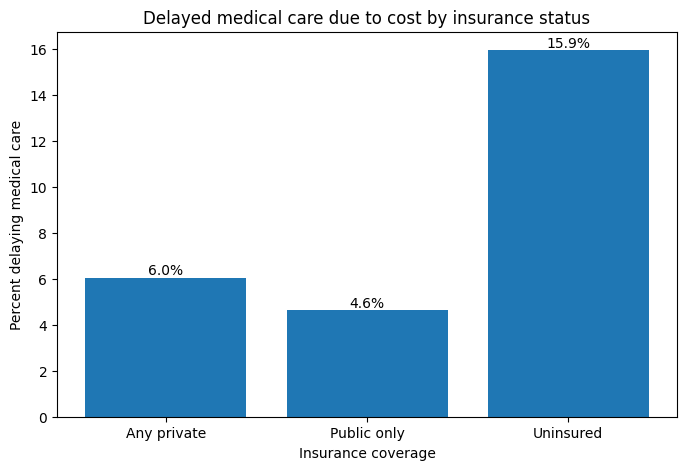

In [23]:
# bar chart for delayed care by insurance status
import matplotlib.pyplot as plt

# add readable insurance category labels
ins_delay["insurance"] = ins_delay["INSCOV23"].map({
    1: "Any private",
    2: "Public only",
    3: "Uninsured"
})

# create bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    ins_delay["insurance"],
    ins_delay["percent_delayed"]
)

plt.xlabel("Insurance coverage")
plt.ylabel("Percent delaying medical care")
plt.title("Delayed medical care due to cost by insurance status")

# Add percentage values above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )


plt.show()

In [24]:
# keep respondents age 18 or older
adult_df = df[df["AGE23X"] >= 18].copy()

# keep respondents with valid age and delayed-care responses
viz2_df = adult_df[
    (df["AGE23X"] >= 0) &
    (df["DLAYCA42"].isin([1, 2]))
].copy()

# create readable labels for delayed-care status
viz2_df["delay_status"] = viz2_df["DLAYCA42"].map({
    1: "Delayed care",
    2: "Did not delay"
})

/tmp/ipykernel_29584/72583011.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  viz2_df = adult_df[


In [25]:
# calculate median age for each delayed-care group
median_age = (
    viz2_df.groupby("delay_status")["AGE23X"]
    .median()
)

median_age

,AGE23X
delay_status,
Delayed care,45.0
Did not delay,54.0


In [26]:
# calculate age summary statistics for each group
age_summary = (
    viz2_df.groupby("delay_status")["AGE23X"]
    .agg(["count", "mean", "median"])
)

age_summary

,count,mean,median
delay_status,,,
Delayed care,1088,46.520221,45.0
Did not delay,13912,52.323821,54.0


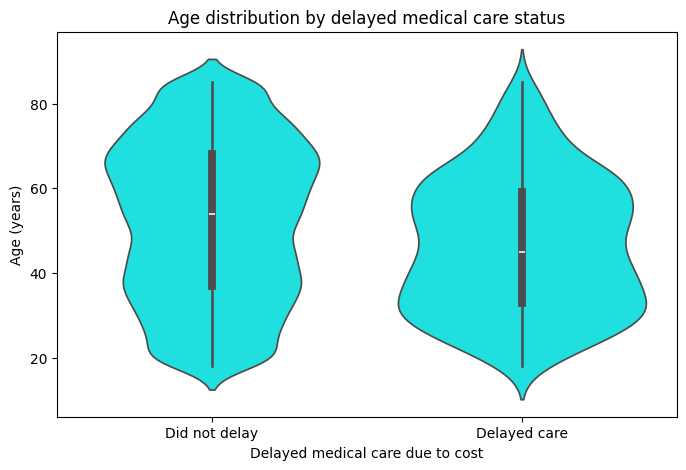

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# create violin plot of age by delayed-care status
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=viz2_df,
    x="delay_status",
    y="AGE23X",
    color="cyan",
    inner="box"
)

plt.xlabel("Delayed medical care due to cost")
plt.ylabel("Age (years)")
plt.title("Age distribution by delayed medical care status")

plt.show()

## **Data Quality Assessment**

- Identify missing values or improperly coded observations.
- Discuss anticipated preprocessing steps.
- Identify potential challenges associated with the dataset.

The MEPS dataset uses negative values to represent special responses such as inapplicable, refused, and don't know rather than standard missing values.
- For the target variable DLAYCA42, 327 observations contained these special codes and will be excluded from the classification analysis, leaving 18,592 valid responses. Similar special codes are present among several predictor variables and will need to be recoded as missing before modeling.
- The analysis will also be restricted to adults aged 18 years and older. Categorical predictors will be appropriately encoded, while age will remain a numeric variable.
- A major challenge is class imbalance, as only 6.2% of valid respondents reported delaying medical care because of cost. Therefore, model performance will be assessed using ROC-AUC, precision, recall, F1-score, and confusion matrices rather than accuracy alone.
- Another consideration is that MEPS is a complex survey with sampling weights and design variables, which may need to be considered depending on the modeling requirements.

In [28]:
# check for valid and special-coded responses in the target variable
df["DLAYCA42"].value_counts(dropna=False).sort_index()

NameError: name 'df' is not defined

,count
DLAYCA42,
-8,31
-7,48
-1,248
1,1156
2,17436


In [29]:
# list predictor variables for the data quality check
predictors = [
    "INSCOV23", "POVCAT23", "AGE23X", "SEX", "RACETHX",
    "EDUCYR", "EMPST53H", "MARRY23X", "RTHLTH53",
    "MNHLTH53", "DIABDX_M18"
]

# count special-coded values for each predictor
special_codes = [-1, -7, -8]

for var in predictors:
    count = df[var].isin(special_codes).sum()
    print(f"{var}: {count} special-coded observations")

INSCOV23: 0 special-coded observations
POVCAT23: 0 special-coded observations
AGE23X: 148 special-coded observations
SEX: 0 special-coded observations
RACETHX: 0 special-coded observations
EDUCYR: 1206 special-coded observations
EMPST53H: 3298 special-coded observations
MARRY23X: 8 special-coded observations
RTHLTH53: 274 special-coded observations
MNHLTH53: 275 special-coded observations
DIABDX_M18: 116 special-coded observations


In [30]:
# check the distribution of the target among valid responses
target_valid["DLAYCA42"].value_counts(normalize=True) * 100

,proportion
DLAYCA42,
2,93.782272
1,6.217728


## **Project Planning**

**Describe**:
- your proposed prediction problem
- the target variable (appropriate for binary classification)
- candidate evaluation metric

**Proposed prediction problem**
The proposed prediction problem is to determine whether selected demographic, socioeconomic, health status, and insurance characteristics can be used to predict whether an adult will delay medical care because of cost. The analysis will use the 2023 Medical Expenditure Panel Survey (MEPS) and focus on adults aged 18 and older. Candidate predictors include health insurance coverage, income level, age, sex, race/ethnicity, education, employment status, marital status, physical health, mental health, and diabetes status. Logistic regression and random forest classification models will be considered.
- Logistic regression provides an interpretable baseline for the binary outcome and allows the relationships between predictors and delayed medical care to be examined.
- Random forest provides a more flexible machine-learning approach that can capture nonlinear relationships and interactions among predictors.
- Comparing their performance will help determine whether the added flexibility of the random forest improves prediction over the simpler logistic regression model.

**Target variable**
The target variable is DLAYCA42, which indicates whether a respondent delayed medical care because of cost. The original MEPS coding is 1 = Yes and 2 = No, with negative values representing special responses such as inapplicable, refused, or don't know. For binary classification, the variable will be recoded as 1 = delayed medical care and 0 = did not delay medical care. Among valid responses, approximately 6.2% reported delaying care, while 93.8% did not.

**Candidate evaluation metric**
The primary evaluation metric will be ROC-AUC (Receiver Operating Characteristic–Area Under the Curve) because the target variable is highly imbalanced, with relatively few respondents reporting delayed medical care. ROC-AUC will measure the model's ability to distinguish between adults who delayed medical care and those who did not across different classification thresholds. Additional metrics, including precision, recall, F1-score, accuracy, and a confusion matrix, will also be reported to provide a more complete assessment of model performance.
